In [65]:
import pyteomics
import lxml
from pyteomics import mzml, mass
import numpy as np
import os
import pandas as pd
from matplotlib import pyplot
import matplotlib
import seaborn as sns
import re
import math
import statsmodels
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [3]:
# create an empty list to store the dataframes
dfs = []

# loop through the range of filenames
for i in range(1, 22):
    # create the filename string using string formatting
    filename = f'E:\\yuming\\2023\\20230310\\metabolome\\mzmine\\gapfill_filtered_range{i}.csv'
    # read the csv file into a dataframe and append it to the list
    dfs.append(pd.read_csv(filename, index_col=0))

In [4]:
dfs[0]

,area,rt,mz_range:min,mz_range:max,charge,fragment_scans,rt_range:min,rt_range:max,mz,intensity_range:min,...,datafile:meta_macro_16_2_range1.mzML:rt_range:min,datafile:meta_macro_16_2_range1.mzML:rt_range:max,datafile:meta_macro_16_2_range1.mzML:feature_state,datafile:meta_macro_16_2_range1.mzML:mz,datafile:meta_macro_16_2_range1.mzML:intensity_range:min,datafile:meta_macro_16_2_range1.mzML:intensity_range:max,datafile:meta_macro_16_2_range1.mzML:isotopes,datafile:meta_macro_16_2_range1.mzML:height,datafile:meta_macro_16_2_range1.mzML:asymmetry_factor,datafile:meta_macro_16_2_range1.mzML:tailing_factor
id,,,,,,,,,,,,,,,,,,,,,
1,52240.0,0.894,102.97020,102.97108,1.0,0,0.884,1.085,102.97063,8044.0,...,0.885,1.082,DETECTED,102.97072,30050.0,40840.0,2.0,40840.0,NaN,NaN
2,45120.0,0.893,103.05415,103.05503,1.0,0,0.884,1.575,103.05445,1002.0,...,0.885,1.557,DETECTED,103.05446,2551.0,147200.0,12.0,147200.0,4.976,3.227
3,28620.0,0.885,106.08611,106.08707,1.0,0,0.884,1.575,106.08668,1192.0,...,0.885,1.557,DETECTED,106.08675,2324.0,121700.0,69.0,121700.0,NaN,NaN
4,70080.0,0.889,114.09122,114.09222,1.0,0,0.884,1.575,114.09163,1200.0,...,0.885,1.557,DETECTED,114.09162,1729.0,285300.0,142.0,285300.0,4.198,2.938
5,14980.0,0.925,119.04906,119.05029,1.0,0,0.884,1.574,119.04943,1039.0,...,0.885,1.557,DETECTED,119.04941,1630.0,62510.0,5.0,62510.0,3.760,2.863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,25790.0,1.017,113.10718,113.10813,NaN,0,0.885,1.567,113.10734,1636.0,...,0.885,1.278,ESTIMATED,113.10729,4377.0,65520.0,NaN,65520.0,0.315,0.658
386,4438.0,0.981,138.01730,138.02191,1.0,0,0.885,1.380,138.01924,2806.0,...,NaN,NaN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
389,13030.0,1.204,111.09156,111.09166,NaN,0,0.885,1.567,111.09159,1010.0,...,0.980,1.464,ESTIMATED,111.09162,3650.0,56390.0,NaN,56390.0,0.467,0.811


In [5]:
[x for x in dfs[0].columns if 'area' in x]

['area',
 'datafile:meta_macro_1_2_range1.mzML:area',
 'datafile:meta_macro_19_range1.mzML:area',
 'datafile:meta_macro_18_2_range1.mzML:area',
 'datafile:meta_macro_24_range1.mzML:area',
 'datafile:meta_macro_21_range1.mzML:area',
 'datafile:meta_macro_23_range1.mzML:area',
 'datafile:meta_macro_6_2_range1.mzML:area',
 'datafile:meta_macro_22_range1.mzML:area',
 'datafile:meta_macro_20_range1.mzML:area',
 'datafile:meta_macro_4_2_range1.mzML:area',
 'datafile:meta_macro_3_2_range1.mzML:area',
 'datafile:meta_macro_5_2_range1.mzML:area',
 'datafile:meta_macro_2_2_range1.mzML:area',
 'datafile:meta_macro_9_2_range1.mzML:area',
 'datafile:meta_macro_8_2_range1.mzML:area',
 'datafile:meta_macro_7_2_range1.mzML:area',
 'datafile:meta_macro_10_2_range1.mzML:area',
 'datafile:meta_macro_13_2_range1.mzML:area',
 'datafile:meta_macro_11_2_range1.mzML:area',
 'datafile:meta_macro_15_2_range1.mzML:area',
 'datafile:meta_macro_17_2_range1.mzML:area',
 'datafile:meta_macro_12_2_range1.mzML:area',


In [6]:
# build a function to get all metabolite features out, make a dataframe, take log2 to that dataframe

def clean_df_log(i=0):
    area_cols = [x for x in dfs[i].columns if 'area' in x]
    area_df = np.log2(dfs[i][area_cols[1:]])
    area_df.index = dfs[i].mz
    q=area_df.dropna()
    #columnames=[item.split(':')[1].split('_ran')[0] for item in q.columns]
    #q.column=columnames
    qq=q.sort_index(axis=1)
    columnames=['B4','B5','B6','C1','C2','C3','C4','C5','C6','D1','A1','D2','D3','D4','D5','D6','A2','A3','A4','A5','A6','B1','B2','B3']
    qq.columns=columnames
    qqq=qq.sort_index(axis=1)
    return(qqq)

# # build a function to get all metabolite features out, make a dataframe, do not take log2 to that dataframe
def clean_df(i=0):
    area_cols = [x for x in dfs[i].columns if 'area' in x]
    area_df = dfs[i][area_cols[1:]]
    area_df.index = dfs[i].mz
    q=area_df.dropna()
    #columnames=[item.split(':')[1].split('_ran')[0] for item in q.columns]
    #q.column=columnames
    qq=q.sort_index(axis=1)
    columnames=['B4','B5','B6','C1','C2','C3','C4','C5','C6','D1','A1','D2','D3','D4','D5','D6','A2','A3','A4','A5','A6','B1','B2','B3']
    qq.columns=columnames
    qqq=qq.sort_index(axis=1)
    return(qqq)

sample=[2,4,6,8,3]
def remove_dul(tar_list=sample):
    res=[]
    [res.append(x) for x in tar_list if x not in res]
    return(res)
 

In [7]:
figure_save_path = r'E:\\project7_SMAD\\figure_3_macro_clustering_analysis\\figure'
file_save_path = r'E:\\project7_SMAD\\figure_3_macro_clustering_analysis\\file'

In [10]:
# combine all 21 dataframes together and make a final dataframe 

all_df=pd.concat([clean_df(i=0),clean_df(i=1),clean_df(i=2),clean_df(i=3),clean_df(i=4),clean_df(i=5),clean_df(i=6),
         clean_df(i=7),clean_df(i=8),clean_df(i=9),clean_df(i=10),clean_df(i=11),clean_df(i=12),clean_df(i=13),
         clean_df(i=14),clean_df(i=15),clean_df(i=16),clean_df(i=17),clean_df(i=18),clean_df(i=19),clean_df(i=20)])

# take the first three treatments out and remove the last irrariation treatment out 
final=all_df.iloc[:,:24]
final.to_excel(r'E:\\project7_SMAD\\figure_3_macro_clustering_analysis\\macro_metabolites_raw.xlsx')
final

C:\Users\jymbc\AppData\Local\Temp\ipykernel_49732\1430584042.py:9: UserWarning: Pandas requires version '3.0.5' or newer of 'xlsxwriter' (version '3.0.1' currently installed).
  final.to_excel(r'E:\\project7_SMAD\\figure_3_macro_clustering_analysis\\macro_metabolites_raw.xlsx')


,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,...,C3,C4,C5,C6,D1,D2,D3,D4,D5,D6
mz,,,,,,,,,,,,,,,,,,,,,
103.05445,19080.0,17900.0,22080.0,21070.0,20310.0,26800.0,20440.0,20940.0,18890.0,22230.0,...,43110.0,37800.0,45120.0,36570.0,21420.0,21130.0,24660.0,23850.0,23830.0,21140.0
106.08668,10790.0,8605.0,11910.0,20410.0,10720.0,18590.0,22860.0,28620.0,17400.0,14570.0,...,17070.0,13110.0,15140.0,14900.0,12280.0,7827.0,19620.0,18550.0,16160.0,14570.0
114.09163,26180.0,30400.0,34120.0,52020.0,35490.0,63800.0,35360.0,33240.0,40230.0,44030.0,...,68400.0,61040.0,59490.0,54470.0,28970.0,31570.0,70080.0,54710.0,55330.0,58830.0
119.04943,6226.0,5279.0,7889.0,6684.0,6524.0,9310.0,5653.0,6031.0,6012.0,6079.0,...,14980.0,13290.0,14360.0,11810.0,6898.0,6167.0,8084.0,7555.0,9112.0,6350.0
120.08104,287200.0,271700.0,343500.0,347100.0,313300.0,422600.0,271400.0,284400.0,248200.0,268900.0,...,664600.0,576500.0,646400.0,616100.0,350700.0,320900.0,389800.0,336100.0,398000.0,318100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015.88826,6693.0,4889.0,6202.0,2281.0,11730.0,1777.0,2303.0,3114.0,1172.0,6488.0,...,1623.0,4697.0,4228.0,3834.0,3413.0,369.9,4228.0,1143.0,6011.0,2358.0
1002.20926,7756.0,1440.0,3469.0,7575.0,3125.0,9785.0,5053.0,7468.0,6951.0,3320.0,...,1678.0,2603.0,2420.0,3609.0,9352.0,2900.0,2548.0,4883.0,3253.0,6210.0
1015.66946,5377.0,5453.0,4331.0,2685.0,3369.0,7853.0,1730.0,360.7,1374.0,7685.0,...,2303.0,3851.0,2821.0,3807.0,5223.0,3824.0,2887.0,8145.0,2283.0,3026.0


In [8]:
# all_df.to_excel(r'E:\\project7_SMAD\\mzmine files\\macro\\metabolites_raw.xlsx')

In [11]:
jiji = all_df[(all_df >= 1000).all(axis=1)]

In [12]:
jiji

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,...,C3,C4,C5,C6,D1,D2,D3,D4,D5,D6
mz,,,,,,,,,,,,,,,,,,,,,
103.05445,19080.0,17900.0,22080.0,21070.0,20310.0,26800.0,20440.0,20940.0,18890.0,22230.0,...,43110.0,37800.0,45120.0,36570.0,21420.0,21130.0,24660.0,23850.0,23830.0,21140.0
106.08668,10790.0,8605.0,11910.0,20410.0,10720.0,18590.0,22860.0,28620.0,17400.0,14570.0,...,17070.0,13110.0,15140.0,14900.0,12280.0,7827.0,19620.0,18550.0,16160.0,14570.0
114.09163,26180.0,30400.0,34120.0,52020.0,35490.0,63800.0,35360.0,33240.0,40230.0,44030.0,...,68400.0,61040.0,59490.0,54470.0,28970.0,31570.0,70080.0,54710.0,55330.0,58830.0
119.04943,6226.0,5279.0,7889.0,6684.0,6524.0,9310.0,5653.0,6031.0,6012.0,6079.0,...,14980.0,13290.0,14360.0,11810.0,6898.0,6167.0,8084.0,7555.0,9112.0,6350.0
120.08104,287200.0,271700.0,343500.0,347100.0,313300.0,422600.0,271400.0,284400.0,248200.0,268900.0,...,664600.0,576500.0,646400.0,616100.0,350700.0,320900.0,389800.0,336100.0,398000.0,318100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988.60125,14990.0,21300.0,15520.0,7088.0,18710.0,8404.0,13730.0,10020.0,9573.0,2898.0,...,8566.0,13480.0,16030.0,10500.0,7589.0,11910.0,6094.0,7644.0,6166.0,10130.0
1002.62052,12880.0,7083.0,8228.0,7066.0,4221.0,1806.0,2809.0,16320.0,5842.0,12950.0,...,4449.0,10510.0,6214.0,6538.0,4778.0,6842.0,7319.0,4535.0,9168.0,8041.0
1002.20926,7756.0,1440.0,3469.0,7575.0,3125.0,9785.0,5053.0,7468.0,6951.0,3320.0,...,1678.0,2603.0,2420.0,3609.0,9352.0,2900.0,2548.0,4883.0,3253.0,6210.0


In [13]:
# apply standardscaler to the final dataframe 

ss = StandardScaler() 
df_ss = ss.fit_transform(jiji)
df_stdscale=pd.DataFrame(df_ss,index=jiji.index,columns=jiji.columns)

df_stdscale


,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,...,C3,C4,C5,C6,D1,D2,D3,D4,D5,D6
mz,,,,,,,,,,,,,,,,,,,,,
103.05445,-0.091885,-0.097171,-0.078570,-0.077137,-0.088079,-0.062762,-0.085175,-0.081398,-0.073314,-0.076691,...,-0.004519,-0.023058,-0.013006,-0.031915,-0.085578,-0.084545,-0.069666,-0.075040,-0.071263,-0.083248
106.08668,-0.115706,-0.126581,-0.111840,-0.079415,-0.116391,-0.093356,-0.077993,-0.058964,-0.078556,-0.102013,...,-0.098293,-0.102052,-0.106745,-0.103645,-0.114139,-0.122699,-0.086848,-0.092371,-0.096598,-0.104911
114.09163,-0.071483,-0.057621,-0.039184,0.029695,-0.043264,0.075118,-0.040897,-0.045468,0.001764,-0.004625,...,0.086555,0.051297,0.031925,0.027335,-0.061985,-0.054603,0.085178,0.025877,0.032789,0.041027
119.04943,-0.128821,-0.137105,-0.124994,-0.126794,-0.128778,-0.127937,-0.129059,-0.124949,-0.118621,-0.130082,...,-0.105820,-0.101476,-0.109184,-0.113873,-0.130957,-0.127460,-0.126176,-0.128326,-0.119880,-0.132015
120.08104,0.678567,0.705860,0.972894,1.048241,0.776894,1.412174,0.659598,0.688195,0.733437,0.738743,...,2.233571,1.700471,1.867032,1.886384,0.943381,0.775209,1.175151,0.946059,1.164709,0.895916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988.60125,-0.103637,-0.086414,-0.100030,-0.125400,-0.092802,-0.131314,-0.105088,-0.113296,-0.106093,-0.140598,...,-0.128918,-0.100868,-0.103962,-0.118210,-0.128798,-0.110989,-0.132960,-0.128035,-0.129611,-0.119551
1002.62052,-0.109701,-0.131397,-0.123885,-0.125476,-0.135577,-0.155901,-0.137499,-0.094893,-0.119219,-0.107368,...,-0.143744,-0.110370,-0.134654,-0.131324,-0.137582,-0.125524,-0.128784,-0.138202,-0.119695,-0.126439
1002.20926,-0.124425,-0.149251,-0.139453,-0.123719,-0.138813,-0.126167,-0.130839,-0.120751,-0.115317,-0.139203,...,-0.153722,-0.135668,-0.146517,-0.141020,-0.123289,-0.136830,-0.145049,-0.137064,-0.139233,-0.132477


In [14]:
df_stdscale.to_csv(r'E:\\project7_SMAD\\figure_3_macro_clustering_analysis\\macro_metabolome_std.csv')

In [15]:
mz=[round(x, 3) for x in df_stdscale.index.tolist()]

In [16]:
df_stdscale['mz_rounded']=mz
df_stdscale

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,...,C4,C5,C6,D1,D2,D3,D4,D5,D6,mz_rounded
mz,,,,,,,,,,,,,,,,,,,,,
103.05445,-0.091885,-0.097171,-0.078570,-0.077137,-0.088079,-0.062762,-0.085175,-0.081398,-0.073314,-0.076691,...,-0.023058,-0.013006,-0.031915,-0.085578,-0.084545,-0.069666,-0.075040,-0.071263,-0.083248,103.054
106.08668,-0.115706,-0.126581,-0.111840,-0.079415,-0.116391,-0.093356,-0.077993,-0.058964,-0.078556,-0.102013,...,-0.102052,-0.106745,-0.103645,-0.114139,-0.122699,-0.086848,-0.092371,-0.096598,-0.104911,106.087
114.09163,-0.071483,-0.057621,-0.039184,0.029695,-0.043264,0.075118,-0.040897,-0.045468,0.001764,-0.004625,...,0.051297,0.031925,0.027335,-0.061985,-0.054603,0.085178,0.025877,0.032789,0.041027,114.092
119.04943,-0.128821,-0.137105,-0.124994,-0.126794,-0.128778,-0.127937,-0.129059,-0.124949,-0.118621,-0.130082,...,-0.101476,-0.109184,-0.113873,-0.130957,-0.127460,-0.126176,-0.128326,-0.119880,-0.132015,119.049
120.08104,0.678567,0.705860,0.972894,1.048241,0.776894,1.412174,0.659598,0.688195,0.733437,0.738743,...,1.700471,1.867032,1.886384,0.943381,0.775209,1.175151,0.946059,1.164709,0.895916,120.081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988.60125,-0.103637,-0.086414,-0.100030,-0.125400,-0.092802,-0.131314,-0.105088,-0.113296,-0.106093,-0.140598,...,-0.100868,-0.103962,-0.118210,-0.128798,-0.110989,-0.132960,-0.128035,-0.129611,-0.119551,988.601
1002.62052,-0.109701,-0.131397,-0.123885,-0.125476,-0.135577,-0.155901,-0.137499,-0.094893,-0.119219,-0.107368,...,-0.110370,-0.134654,-0.131324,-0.137582,-0.125524,-0.128784,-0.138202,-0.119695,-0.126439,1002.621
1002.20926,-0.124425,-0.149251,-0.139453,-0.123719,-0.138813,-0.126167,-0.130839,-0.120751,-0.115317,-0.139203,...,-0.135668,-0.146517,-0.141020,-0.123289,-0.136830,-0.145049,-0.137064,-0.139233,-0.132477,1002.209


In [17]:
round_df_stdscale=df_stdscale

round_df_stdscale.index=df_stdscale['mz_rounded']
# round_df_stdscale=round_df_stdscale.iloc[:,:24]
round_df_stdscale

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,...,C4,C5,C6,D1,D2,D3,D4,D5,D6,mz_rounded
mz_rounded,,,,,,,,,,,,,,,,,,,,,
103.054,-0.091885,-0.097171,-0.078570,-0.077137,-0.088079,-0.062762,-0.085175,-0.081398,-0.073314,-0.076691,...,-0.023058,-0.013006,-0.031915,-0.085578,-0.084545,-0.069666,-0.075040,-0.071263,-0.083248,103.054
106.087,-0.115706,-0.126581,-0.111840,-0.079415,-0.116391,-0.093356,-0.077993,-0.058964,-0.078556,-0.102013,...,-0.102052,-0.106745,-0.103645,-0.114139,-0.122699,-0.086848,-0.092371,-0.096598,-0.104911,106.087
114.092,-0.071483,-0.057621,-0.039184,0.029695,-0.043264,0.075118,-0.040897,-0.045468,0.001764,-0.004625,...,0.051297,0.031925,0.027335,-0.061985,-0.054603,0.085178,0.025877,0.032789,0.041027,114.092
119.049,-0.128821,-0.137105,-0.124994,-0.126794,-0.128778,-0.127937,-0.129059,-0.124949,-0.118621,-0.130082,...,-0.101476,-0.109184,-0.113873,-0.130957,-0.127460,-0.126176,-0.128326,-0.119880,-0.132015,119.049
120.081,0.678567,0.705860,0.972894,1.048241,0.776894,1.412174,0.659598,0.688195,0.733437,0.738743,...,1.700471,1.867032,1.886384,0.943381,0.775209,1.175151,0.946059,1.164709,0.895916,120.081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988.601,-0.103637,-0.086414,-0.100030,-0.125400,-0.092802,-0.131314,-0.105088,-0.113296,-0.106093,-0.140598,...,-0.100868,-0.103962,-0.118210,-0.128798,-0.110989,-0.132960,-0.128035,-0.129611,-0.119551,988.601
1002.621,-0.109701,-0.131397,-0.123885,-0.125476,-0.135577,-0.155901,-0.137499,-0.094893,-0.119219,-0.107368,...,-0.110370,-0.134654,-0.131324,-0.137582,-0.125524,-0.128784,-0.138202,-0.119695,-0.126439,1002.621
1002.209,-0.124425,-0.149251,-0.139453,-0.123719,-0.138813,-0.126167,-0.130839,-0.120751,-0.115317,-0.139203,...,-0.135668,-0.146517,-0.141020,-0.123289,-0.136830,-0.145049,-0.137064,-0.139233,-0.132477,1002.209


In [18]:
# round_df_stdscale.to_excel(r'E:\\project7_SMAD\\figure_3_macro_clustering_analysis\\rounded_macro_metabolome_std.xlsx')

In [20]:
# function for oneway_ANOVA analysis 
def oneway_ANOVA(result=df_stdscale):
    pval=[]
    for i in range(len(result)):
        aa=result.iloc[i,:6].tolist()
        bb=result.iloc[i,6:12].tolist()
        cc=result.iloc[i,12:18].tolist()
        dd=result.iloc[i,18:24].tolist()
        p_value=f_oneway(aa,bb,cc,dd)[1]
        pval.append([i,p_value])
        fl = pd.DataFrame(pval)
        fl.columns = ['number', 'p_value']
    return(fl)

In [21]:
# calculate the p values for different treatments 

df_pval=oneway_ANOVA(result=round_df_stdscale)
df_pval['index_name']=round_df_stdscale.index.values.tolist()
df_pval

,number,p_value,index_name
0,0,0.000002,103.054
1,1,0.017089,106.087
2,2,0.705904,114.092
3,3,0.000098,119.049
4,4,0.000010,120.081
...,...,...,...
7300,7300,0.145156,988.601
7301,7301,0.603380,1002.621
7302,7302,0.146566,1002.209
7303,7303,0.975956,1020.666


In [25]:
# apply FDR correction to the p-values 

from statsmodels.stats import multitest
pvals_adjusted = multitest.multipletests(df_pval['p_value'].tolist(), method='fdr_bh')
print(len([item for item in pvals_adjusted[1] if item<0.01]))

# FDR correction for all p_values from Standard scaler less than 0.01
FDR_res=statsmodels.stats.multitest.fdrcorrection(df_pval['p_value'].tolist(), alpha=0.01, method='indep', is_sorted=False)[0]


2363


In [26]:
# calculate the pvalues < 0.01 after FDR correction 

yuyu=[]
for item in range(len(FDR_res)):
    if FDR_res[item]== True:
        yuyu.append(item)
len(yuyu)

2363

In [31]:
# locate the significant proteins from df_pval dataframe, aiming to find the protein names out 

sig_metas=df_pval.loc[yuyu]
sig_metas
#sig_pros.to_excel(r'D:\\project7_SMAD\\cluster_analysis_macro_proteins\\Stardard_scaler\\sig_proteins.xlsx')

,number,p_value,index_name
0,0,2.074728e-06,103.054
3,3,9.754232e-05,119.049
4,4,9.746757e-06,120.081
7,7,5.357540e-06,130.050
8,8,7.193509e-08,132.077
...,...,...,...
7267,7267,3.440529e-04,1008.593
7268,7268,2.946937e-05,1010.494
7286,7286,1.484893e-04,989.487
7296,7296,1.519216e-03,988.561


In [29]:
#calculate the mean value from 6 repeats in each treatment
df_plot = round_df_stdscale

con=df_plot.iloc[:,:6].mean(axis=1).tolist()
lps=df_plot.iloc[:,6:12].mean(axis=1).tolist()
IL_4=df_plot.iloc[:,12:18].mean(axis=1).tolist()
IRD=df_plot.iloc[:,18:24].mean(axis=1).tolist()
newdict={'Con':con,'LPS':lps,'IL_4':IL_4,'IRD':IRD}

df_mean=pd.DataFrame.from_dict(newdict)
df_mean.index=df_plot.index
df_mean

,Con,LPS,IL_4,IRD
mz_rounded,,,,
103.054,-0.082601,-0.077138,-0.029637,-0.078223
106.087,-0.107215,-0.082841,-0.108082,-0.102928
114.092,-0.017790,-0.000226,0.015540,0.011380
119.049,-0.129072,-0.125604,-0.111959,-0.127469
120.081,0.932438,0.757489,1.719914,0.983404
...,...,...,...,...
988.601,-0.106600,-0.116816,-0.108671,-0.124991
1002.621,-0.130323,-0.121793,-0.131664,-0.129371
1002.209,-0.133638,-0.129304,-0.142023,-0.135657


In [255]:
# 按行进行标准归一化
#scaler=StandardScaler()
#df_mean.T

#proname=df_mean.T.columns.tolist()
#k=df_mean.T
#k[proname]=scaler.fit_transform(k[proname])

# 按行进行标准化后的 dataframe
#dfdf=k.T
#dfdf

In [32]:
# pick the significant m/z features out from the df_mean dataframe 

df_sig=df_mean.loc[sig_metas['index_name'].tolist()]
df_sig

,Con,LPS,IL_4,IRD
mz_rounded,,,,
103.054,-0.082601,-0.077138,-0.029637,-0.078223
119.049,-0.129072,-0.125604,-0.111959,-0.127469
120.081,0.932438,0.757489,1.719914,0.983404
130.050,-0.114334,-0.112878,-0.096270,-0.118079
132.077,4.381952,2.351530,5.892842,3.537485
...,...,...,...,...
1010.494,-0.091404,-0.115019,-0.060530,-0.099193
989.487,-0.110029,-0.100697,-0.127452,-0.110090
989.487,-0.113053,-0.106608,-0.132776,-0.116019


In [76]:
df_sig_original=round_df_stdscale.loc[sig_metas['index_name'].tolist()]
df_sig_original

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,...,C4,C5,C6,D1,D2,D3,D4,D5,D6,mz_rounded
mz_rounded,,,,,,,,,,,,,,,,,,,,,
103.054,-0.091885,-0.097171,-0.078570,-0.077137,-0.088079,-0.062762,-0.085175,-0.081398,-0.073314,-0.076691,...,-0.023058,-0.013006,-0.031915,-0.085578,-0.084545,-0.069666,-0.075040,-0.071263,-0.083248,103.054
119.049,-0.128821,-0.137105,-0.124994,-0.126794,-0.128778,-0.127937,-0.129059,-0.124949,-0.118621,-0.130082,...,-0.101476,-0.109184,-0.113873,-0.130957,-0.127460,-0.126176,-0.128326,-0.119880,-0.132015,119.049
120.081,0.678567,0.705860,0.972894,1.048241,0.776894,1.412174,0.659598,0.688195,0.733437,0.738743,...,1.700471,1.867032,1.886384,0.943381,0.775209,1.175151,0.946059,1.164709,0.895916,120.081
130.050,-0.115620,-0.119794,-0.111480,-0.114313,-0.113291,-0.111504,-0.116363,-0.112099,-0.106233,-0.116459,...,-0.083335,-0.089611,-0.098912,-0.122951,-0.114545,-0.119644,-0.115655,-0.113874,-0.121803,130.050
132.077,3.830259,4.481498,4.167329,4.976003,3.849278,4.987346,1.770704,1.771048,2.634302,2.673939,...,6.232452,5.070676,7.281509,3.319222,2.545654,4.070201,3.744966,3.652044,3.892825,132.077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010.494,-0.101109,-0.106031,-0.058812,-0.109998,-0.080314,-0.092163,-0.119621,-0.109762,-0.115388,-0.105947,...,-0.043534,-0.063690,-0.074715,-0.076547,-0.109584,-0.109178,-0.097963,-0.086325,-0.115562,1010.494
989.487,-0.110706,-0.107454,-0.115733,-0.108755,-0.109748,-0.107777,-0.084552,-0.095594,-0.089673,-0.112724,...,-0.121178,-0.124752,-0.135240,-0.118170,-0.092633,-0.119098,-0.115033,-0.105055,-0.110550,989.487
989.487,-0.120379,-0.103816,-0.108209,-0.113415,-0.115741,-0.116758,-0.090280,-0.092527,-0.110293,-0.124747,...,-0.130264,-0.135498,-0.134873,-0.115108,-0.105683,-0.115689,-0.123523,-0.112024,-0.124088,989.487


In [77]:
df_sig_original.to_csv(r'E:\\project7_SMAD\\figure_3_macro_clustering_analysis\\macro_metabolome_sig_mzs.csv')

In [43]:
# df_sig.to_csv(r'E:\\project7_SMAD\\figure_3_macro_clustering_analysis\\macro_metabolome_sig_meanvalue.csv')

In [258]:
# build a function to see the elbow of clusters 

def optimise_k_means(data,max_k):
    means=[]
    inertias=[]
    for k in range(1,max_k):
        kmeans=KMeans(n_clusters=k)
        kmeans.fit(data)
        means.append(k)
        inertias.append(kmeans.inertia_)
    fig=plt.subplots(figsize=(10,5))
    plt.plot(means,inertias)
    plt.xlabel('number of clusters')
    plt.ylabel('inertia')
    plt.show()

In [259]:
#optimise_k_means(df_sig,10)

In [260]:
kmeans=KMeans(n_clusters=4)
kmeans.fit(df_sig[['Con','LPS','IL_4']])

df_sig['kmeans']=kmeans.labels_
df_sig

,Con,LPS,IL_4,kmeans
mz_rounded,,,,
103.054,-0.204901,-0.204631,-0.202280,0
119.049,-0.204362,-0.204213,-0.203629,0
120.081,-0.211203,-0.218705,-0.177434,3
130.050,-0.204279,-0.204222,-0.203571,0
132.077,-0.190242,-0.271045,-0.130115,3
...,...,...,...,...
996.934,-0.204050,-0.204267,-0.204223,0
997.035,-0.204002,-0.204296,-0.204185,0
1010.494,-0.204123,-0.204243,-0.203968,0


# Trying to match significant meta m/z to the identified m/z

In [35]:
# input the identified m/z features from GNPS results 
fileslist = []
dir = 'E:\\project7_SMAD\\meta_identification'
for file in os.listdir(dir):
    if file.endswith(".tsv"):
        fileslist.append(os.path.join(dir, file))
print(fileslist)



['E:\\project7_SMAD\\meta_identification\\meta_293_macro_st.tsv', 'E:\\project7_SMAD\\meta_identification\\meta_macro_st.tsv', 'E:\\project7_SMAD\\meta_identification\\meta_293T_st.tsv', 'E:\\project7_SMAD\\meta_identification\\meta_293T.tsv', 'E:\\project7_SMAD\\meta_identification\\meta_macro.tsv', 'E:\\project7_SMAD\\meta_identification\\293_macro.tsv']


In [36]:
meta_macro=pd.read_csv(fileslist[1],delimiter="\t", header=0)


In [37]:
# filter the dataframe with 'MZErrorPPM' < 30 ppm

meta_macro_filter=meta_macro[meta_macro['MZErrorPPM'] < 30]

In [38]:
len(meta_macro_filter)

449

In [39]:
# try to match the significant metabolite m/z features to the identified m/z features from GNPS

scan_20_25_30=meta_macro_filter[meta_macro_filter['full_CCMS_path']=='yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30.mzXML']
scan_35_40_45=meta_macro_filter[meta_macro_filter['full_CCMS_path']=='yuming/ST_Macro_mix2_meta_DDA_Qslices_35_40_45.mzXML']
scan_5_10_15=meta_macro_filter[meta_macro_filter['full_CCMS_path']=='yuming/ST_Macro_mix2_meta_DDA_Qslices_5_10_15.mzXML']

In [40]:
scan_20_25_30

,rowid,ccms_row_id,#Scan#,Adduct,CAS_Number,Charge,Compound_Name,Compound_Source,Data_Collector,ExactMass,...,class,full_CCMS_path,internalFilename,npclassifier_class,npclassifier_pathway,npclassifier_superclass,subclass,superclass,tags,id
0,1,1,408,[M+H]+,NaN,1,Massbank:PB000420 Arginine|2-amino-5-(diaminom...,Isolated,Massbank,0.000,...,Carboxylic acids and derivatives,yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30...,spec-00000.mzXML,Aminoacids,Amino acids and Peptides,Small peptides,"Amino acids, peptides, and analogues",Organic acids and derivatives,NaN,0
1,2,2,914,[M+H]+,NaN,1,Glutathione,isolated,MoNA:VF-NPL-QTOF002082,0.000,...,Carboxylic acids and derivatives,yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30...,spec-00000.mzXML,NaN,NaN,NaN,"Amino acids, peptides, and analogues",Organic acids and derivatives,NaN,1
2,3,3,813,[M+H]+,NaN,1,Massbank:PB000420 Arginine|2-amino-5-(diaminom...,Isolated,Massbank,0.000,...,Carboxylic acids and derivatives,yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30...,spec-00000.mzXML,Aminoacids,Amino acids and Peptides,Small peptides,"Amino acids, peptides, and analogues",Organic acids and derivatives,NaN,2
3,4,4,4,M+H,NaN,1,L-(+)-Arginine - 40.0 eV,Isolated,Data Collector,0.000,...,Carboxylic acids and derivatives,yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30...,spec-00000.mzXML,Aminoacids,Amino acids and Peptides,Small peptides,"Amino acids, peptides, and analogues",Organic acids and derivatives,NaN,3
9,10,10,811,M,NaN,1,CHOLINE,isolated,MoNA:MoNA032252,0.000,...,Organonitrogen compounds,yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30...,spec-00000.mzXML,NaN,NaN,NaN,Quaternary ammonium salts,Organic nitrogen compounds,NaN,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,521,521,601,M+H,103231.0,1,"Spectral Match to Hexanedioic acid, bis(2-ethy...",Isolated,Data deposited by eriche,0.000,...,NaN,yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30...,spec-00000.mzXML,NaN,NaN,NaN,NaN,NaN,NaN,520
523,524,524,1068,M+Na,NaN,1,Spectral Match to 1-Hexadecanoyl-sn-glycero-3-...,Isolated,Data deposited by pmallard,495.332,...,Glycerophospholipids,yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30...,spec-00000.mzXML,NaN,NaN,NaN,Glycerophosphocholines,Lipids and lipid-like molecules,NaN,523
524,525,525,938,M+H,70188.0,1,"Spectral Match to L-Glutathione, reduced from ...",Isolated,Data deposited by eriche,307.084,...,Carboxylic acids and derivatives,yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30...,spec-00000.mzXML,Tripeptides,Amino acids and Peptides,Small peptides,"Amino acids, peptides, and analogues",Organic acids and derivatives,NaN,524
527,528,528,585,Cat,16287711.0,1,Spectral Match to Benzyltetradecyldimethylammo...,Isolated,Data deposited by lfnothias,0.000,...,NaN,yuming/ST_Macro_mix2_meta_DDA_Qslices_20_25_30...,spec-00000.mzXML,NaN,NaN,NaN,NaN,NaN,NaN,527


In [41]:
scan_20_25_30['Compound_Name'].tolist()[0]

'Massbank:PB000420 Arginine|2-amino-5-(diaminomethylideneamino)pentanoic acid'

In [42]:
# input mzml files for these meta identification files with DDA and different CV and Qslices  

mzmlslist = []
dir = 'E:\\yuming\\2023\\20230401\\ST_MACRO'
for file in os.listdir(dir):
    if file.endswith(".mzML") and 'Macro' in file:
        mzmlslist.append(os.path.join(dir, file))
print(mzmlslist)



['E:\\yuming\\2023\\20230401\\ST_MACRO\\ST_Macro_mix2_meta_DDA_Qslices_35_40_45.mzML', 'E:\\yuming\\2023\\20230401\\ST_MACRO\\ST_Macro_mix2_meta_DDA_Qslices_5_10_15.mzML', 'E:\\yuming\\2023\\20230401\\ST_MACRO\\ST_Macro_mix2_meta_DDA_Qslices_20_25_30.mzML']


In [43]:
# 
tmp_5_10_15 = pyteomics.mzml.read(mzmlslist[1], use_index=True)
tmp_20_25_30 = pyteomics.mzml.read(mzmlslist[2], use_index=True)
tmp_35_40_45 = pyteomics.mzml.read(mzmlslist[0], use_index=True)

In [44]:
list_cv1,list_cv2,list_cv3=[],[],[]

for number in list(np.array(scan_5_10_15['#Scan#'].tolist())-1):
    list_cv1.append(float(tmp_5_10_15.get_by_index(number)['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']))
for number in list(np.array(scan_20_25_30['#Scan#'].tolist())-1):
    list_cv2.append(float(tmp_20_25_30.get_by_index(number)['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']))
for number in list(np.array(scan_35_40_45['#Scan#'].tolist())-1):
    list_cv3.append(float(tmp_35_40_45.get_by_index(number)['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']))

In [45]:
new_df1=scan_5_10_15.iloc[:,:7]
new_df2=scan_20_25_30.iloc[:,:7]
new_df3=scan_35_40_45.iloc[:,:7]


In [46]:
new_df1['mz']=list_cv1
new_df2['mz']=list_cv2
new_df3['mz']=list_cv3

In [47]:
newdf_all=pd.concat([new_df1,new_df2,new_df3])


In [48]:
newdf_all['mz_rounded']=[round(num, 3) for num in newdf_all['mz']]
newdf_all

,rowid,ccms_row_id,#Scan#,Adduct,CAS_Number,Charge,Compound_Name,mz,mz_rounded
4,5,5,826,M+H-CH3NH2,526318.0,1,Spectral Match to Abrine from NIST14,188.070602,188.071
5,6,6,7,M+H,NaN,1,Massbank:UA005501 L-Phenylalanine|(2S)-2-Azani...,166.086166,166.086
6,7,7,411,M+H,NaN,1,Histidine,156.076706,156.077
14,15,15,430,M+H-CH3NH2,526318.0,1,Spectral Match to Abrine from NIST14,188.070602,188.071
26,27,27,839,M+H-H2O,NaN,1,pyridoxal CollisionEnergy:205060,150.054962,150.055
...,...,...,...,...,...,...,...,...,...
526,527,527,678,M+H,NaN,1,Massbank:RP025803 1-Stearoyl-sn-glycero-3-phos...,525.374146,525.374
528,529,529,660,M+H,NaN,1,PE(20:4/0:0); [M+H]+ C25H45N1O7P1,502.292328,502.292
533,534,534,608,M+H,13962055.0,1,Spectral Match to Oleoyl L-carnitine from NIST14,426.357635,426.358
535,536,536,421,M+H,NaN,1,PE(P-16:0/22:6); [M+H]+ C43H75N1O7P1,748.527222,748.527


In [49]:
def clean_mixed_items(items):
    cleaned_items = []
    for item in items:
        if 'Massbank' in item:
            # Remove 'massbank:xxxx' part
            cleaned_item = item.split(' ', 1)[1]
        elif 'CollisionEnergy:' in item:
            # Remove 'collisionenergy:xxxx' part
            cleaned_item = item.split(' CollisionEnergy')[0]
        elif 'Spectral Match to' in item:
            cleaned_item = item.split('Match to ')[-1].split('from')[0]
        else:
            # If the item doesn't match any known pattern, keep it as is
            cleaned_item = item
        cleaned_items.append(cleaned_item)
    return cleaned_items

In [50]:
newdf_all["metabolites"] = clean_mixed_items(newdf_all['Compound_Name'].tolist())

In [51]:
# get the significant m/z and corresponding compound name out  named the dataframe to name_df

name_df=newdf_all[newdf_all['mz_rounded'].isin ([round(num, 3) for num in final.index])]
name_df


,rowid,ccms_row_id,#Scan#,Adduct,CAS_Number,Charge,Compound_Name,mz,mz_rounded,metabolites
4,5,5,826,M+H-CH3NH2,526318.0,1,Spectral Match to Abrine from NIST14,188.070602,188.071,Abrine
6,7,7,411,M+H,NaN,1,Histidine,156.076706,156.077,Histidine
14,15,15,430,M+H-CH3NH2,526318.0,1,Spectral Match to Abrine from NIST14,188.070602,188.071,Abrine
26,27,27,839,M+H-H2O,NaN,1,pyridoxal CollisionEnergy:205060,150.054962,150.055,pyridoxal
27,28,28,851,M+,62497.0,1,Spectral Match to Choline cation from NIST14,104.106956,104.107,Choline cation
...,...,...,...,...,...,...,...,...,...,...
522,523,523,197,M+H,NaN,1,TOP 8 Psoriasis feature - Unknown FeatureID=4262,438.297791,438.298,TOP 8 Psoriasis feature - Unknown FeatureID=4262
528,529,529,660,M+H,NaN,1,PE(20:4/0:0); [M+H]+ C25H45N1O7P1,502.292328,502.292,PE(20:4/0:0); [M+H]+ C25H45N1O7P1
533,534,534,608,M+H,13962055.0,1,Spectral Match to Oleoyl L-carnitine from NIST14,426.357635,426.358,Oleoyl L-carnitine
535,536,536,421,M+H,NaN,1,PE(P-16:0/22:6); [M+H]+ C43H75N1O7P1,748.527222,748.527,PE(P-16:0/22:6); [M+H]+ C43H75N1O7P1


In [52]:
list_cval=list_cv1+list_cv2+list_cv3
identified_mz_round=[round(num, 3) for num in list_cval]
len(list_cval)

449

In [53]:
#identified_mz_round

In [78]:
# dfsig_meta=pd.read_excel(r'E:\\project7_SMAD\\figure_3_macro_clustering_analysis\\macro_metabolome_sig_meanvalue.xlsx')

df_meta_sig=pd.read_csv(r'E:\\project7_SMAD\\figure_3_macro_clustering_analysis\\macro_metabolome_sig_mzs.csv')


In [79]:
df_meta_sig

,mz_rounded,A1,A2,A3,A4,A5,A6,B1,B2,B3,...,C4,C5,C6,D1,D2,D3,D4,D5,D6,mz_rounded.1
0,103.054,-0.091885,-0.097171,-0.078570,-0.077137,-0.088079,-0.062762,-0.085175,-0.081398,-0.073314,...,-0.023058,-0.013006,-0.031915,-0.085578,-0.084545,-0.069666,-0.075040,-0.071263,-0.083248,103.054
1,119.049,-0.128821,-0.137105,-0.124994,-0.126794,-0.128778,-0.127937,-0.129059,-0.124949,-0.118621,...,-0.101476,-0.109184,-0.113873,-0.130957,-0.127460,-0.126176,-0.128326,-0.119880,-0.132015,119.049
2,120.081,0.678567,0.705860,0.972894,1.048241,0.776894,1.412174,0.659598,0.688195,0.733437,...,1.700471,1.867032,1.886384,0.943381,0.775209,1.175151,0.946059,1.164709,0.895916,120.081
3,130.050,-0.115620,-0.119794,-0.111480,-0.114313,-0.113291,-0.111504,-0.116363,-0.112099,-0.106233,...,-0.083335,-0.089611,-0.098912,-0.122951,-0.114545,-0.119644,-0.115655,-0.113874,-0.121803,130.050
4,132.077,3.830259,4.481498,4.167329,4.976003,3.849278,4.987346,1.770704,1.771048,2.634302,...,6.232452,5.070676,7.281509,3.319222,2.545654,4.070201,3.744966,3.652044,3.892825,132.077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2509,1010.494,-0.101109,-0.106031,-0.058812,-0.109998,-0.080314,-0.092163,-0.119621,-0.109762,-0.115388,...,-0.043534,-0.063690,-0.074715,-0.076547,-0.109584,-0.109178,-0.097963,-0.086325,-0.115562,1010.494
2510,989.487,-0.110706,-0.107454,-0.115733,-0.108755,-0.109748,-0.107777,-0.084552,-0.095594,-0.089673,...,-0.121178,-0.124752,-0.135240,-0.118170,-0.092633,-0.119098,-0.115033,-0.105055,-0.110550,989.487
2511,989.487,-0.120379,-0.103816,-0.108209,-0.113415,-0.115741,-0.116758,-0.090280,-0.092527,-0.110293,...,-0.130264,-0.135498,-0.134873,-0.115108,-0.105683,-0.115689,-0.123523,-0.112024,-0.124088,989.487
2512,988.561,-0.139332,-0.144866,-0.144412,-0.139096,-0.144499,-0.144230,-0.127474,-0.126085,-0.135283,...,-0.138580,-0.147761,-0.144373,-0.144163,-0.135158,-0.144715,-0.146132,-0.142972,-0.147130,988.561


In [223]:
# name_df

In [81]:
final2 = df_meta_sig[df_meta_sig['mz_rounded'].isin (identified_mz_round)]
final3 = final2.drop_duplicates(subset='mz_rounded', keep='first')
final3

,mz_rounded,A1,A2,A3,A4,A5,A6,B1,B2,B3,...,C4,C5,C6,D1,D2,D3,D4,D5,D6,mz_rounded.1
2,120.081,0.678567,0.705860,0.972894,1.048241,0.776894,1.412174,0.659598,0.688195,0.733437,...,1.700471,1.867032,1.886384,0.943381,0.775209,1.175151,0.946059,1.164709,0.895916,120.081
4,132.077,3.830259,4.481498,4.167329,4.976003,3.849278,4.987346,1.770704,1.771048,2.634302,...,6.232452,5.070676,7.281509,3.319222,2.545654,4.070201,3.744966,3.652044,3.892825,132.077
21,104.107,11.212368,13.774257,12.908271,10.616185,9.659261,12.656414,3.750752,4.484459,6.083863,...,9.975775,9.810794,12.859020,13.625055,9.434130,13.196495,14.899389,11.936555,12.683407,104.107
26,129.139,1.006438,0.686243,0.537483,0.517705,0.622198,0.748118,0.325732,0.310789,0.406247,...,0.774238,0.511909,0.935063,0.331530,0.331809,0.325932,0.321464,0.255989,0.243711,129.139
39,165.055,-0.121873,-0.126942,-0.113639,-0.117758,-0.121217,-0.117690,-0.126922,-0.122953,-0.114388,...,-0.089254,-0.091518,-0.094907,-0.120201,-0.117677,-0.115894,-0.117192,-0.110505,-0.121180,165.055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2176,786.600,11.801443,12.094156,12.924627,14.057593,11.569353,13.655107,11.318380,11.238045,14.548570,...,14.467763,15.510816,15.063544,8.481513,8.516355,9.477112,9.307462,9.175051,9.933465,786.600
2177,788.615,3.453826,3.737951,4.239298,4.116514,4.300968,4.242053,3.154245,2.532871,3.088497,...,4.021651,4.170179,3.795978,2.559253,2.656361,2.644154,2.646855,2.569574,2.886491,788.615
2216,818.605,1.628845,1.764228,1.765206,1.897375,1.564549,1.780722,1.339201,1.671730,1.852917,...,1.349814,1.696000,1.664277,2.072397,1.950821,2.086758,2.380667,2.003069,2.164384,818.605
2233,836.615,3.209576,3.592405,3.627563,4.019865,3.282450,3.697989,3.127535,3.167042,3.877973,...,2.978000,3.560467,3.541101,4.062942,3.884459,4.608847,4.814299,4.342420,4.802878,836.615


In [82]:
final3.set_index(['mz_rounded'], inplace = True)

In [83]:
mz_to_metabolite = dict(zip(name_df['mz_rounded'], name_df['metabolites']))
final3.index = final3.index.map(mz_to_metabolite)

In [84]:
final3 = final3[~final3.index.duplicated(keep='first')]

In [85]:
final3

,A1,A2,A3,A4,A5,A6,B1,B2,B3,B4,...,C4,C5,C6,D1,D2,D3,D4,D5,D6,mz_rounded.1
mz_rounded,,,,,,,,,,,,,,,,,,,,,
2-Amino-1-phenylethanol,0.678567,0.705860,0.972894,1.048241,0.776894,1.412174,0.659598,0.688195,0.733437,0.738743,...,1.700471,1.867032,1.886384,0.943381,0.775209,1.175151,0.946059,1.164709,0.895916,120.081
CREATINE,3.830259,4.481498,4.167329,4.976003,3.849278,4.987346,1.770704,1.771048,2.634302,2.673939,...,6.232452,5.070676,7.281509,3.319222,2.545654,4.070201,3.744966,3.652044,3.892825,132.077
CHOLINE,11.212368,13.774257,12.908271,10.616185,9.659261,12.656414,3.750752,4.484459,6.083863,6.448134,...,9.975775,9.810794,12.859020,13.625055,9.434130,13.196495,14.899389,11.936555,12.683407,104.107
"Spermine|N,N_-Bis(3-aminopropyl)-1,4-butanediamine",1.006438,0.686243,0.537483,0.517705,0.622198,0.748118,0.325732,0.310789,0.406247,0.226349,...,0.774238,0.511909,0.935063,0.331530,0.331809,0.325932,0.321464,0.255989,0.243711,129.139
L-Tyrosine,-0.121873,-0.126942,-0.113639,-0.117758,-0.121217,-0.117690,-0.126922,-0.122953,-0.114388,-0.127348,...,-0.089254,-0.091518,-0.094907,-0.120201,-0.117677,-0.115894,-0.117192,-0.110505,-0.121180,165.055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PC(17:0/18:1); [M+H]+ C43H85N1O8P1,0.548396,0.676434,0.744884,0.807308,0.713422,0.675452,0.717171,0.697543,0.891402,0.867337,...,0.774558,0.778306,0.777502,0.486524,0.570430,0.567982,0.530752,0.637843,0.539149,774.600
1-Stearoyl-2-linoleoyl-sn-glycero-3-phosphocholine,11.801443,12.094156,12.924627,14.057593,11.569353,13.655107,11.318380,11.238045,14.548570,15.036519,...,14.467763,15.510816,15.063544,8.481513,8.516355,9.477112,9.307462,9.175051,9.933465,786.600
PC(P-18:0/22:6); [M+H]+ C48H85N1O7P1,1.628845,1.764228,1.765206,1.897375,1.564549,1.780722,1.339201,1.671730,1.852917,1.972786,...,1.349814,1.696000,1.664277,2.072397,1.950821,2.086758,2.380667,2.003069,2.164384,818.605


In [86]:
final3.to_csv(f'{file_save_path}/metabolome_dysregu_sig_macro_withnames.csv')

In [52]:
# 按行进行标准归一化
def standardscaler_row(df):
    scaler=StandardScaler()
    proname=df.T.columns
    k=df.T
    dfdf_pro=scaler.fit_transform(k)
    # 按行进行标准化后的 dataframe
    dfpro_stdbyrow=pd.DataFrame(dfdf_pro.T,index=df.index,columns=df.columns)
    return dfpro_stdbyrow

In [54]:
after_rowss =standardscaler_row(final3)

In [56]:
after_rowss.to_csv(f'{file_save_path}/metabolome_dysregu_sig_ss.csv')

In [299]:
#  calculate mean values of each drug, dmso and dfo 
df = standardscaler_row(final3)
treatment=['Con']*6+['LPS']*6+['IL-4']*6+['irra']*6
interval = 6
chunks = []
total_columns = df.shape[1]
num_chunks = total_columns // interval 
mean_dict = {} 
for i in range(0, total_columns, interval):
    # Create a chunk by slicing the DataFrame
    drugmean = df.iloc[:, i:i+6].mean(axis = 1).tolist()
    drugname4 = treatment[i]
    mean_dict[drugname4] = drugmean
df_mean = pd.DataFrame(mean_dict)  
df_mean.index = df.index
df_mean.to_csv(f'{file_save_path}/metabolome_dysregu_sig_mean.csv')
df_mean

,Con,LPS,IL-4,irra
mz_rounded,,,,
2-Amino-1-phenylethanol,-0.381689,-0.784263,1.430364,-0.264412
CREATINE,0.240761,-1.192809,1.307518,-0.355471
CHOLINE,0.577162,-1.455879,0.046067,0.832651
"Spermine|N,N_-Bis(3-aminopropyl)-1,4-butanediamine",0.568742,-0.862708,1.087523,-0.793557
L-Tyrosine,-0.494723,-0.745634,1.487652,-0.247295
pyridoxal,0.389653,-1.542618,0.790889,0.362075
HISTIDINE,-0.209223,-1.030818,1.496753,-0.256712
Abrine,-0.352984,-0.929706,1.506665,-0.223975
Arginine|2-amino-5-(diaminomethylideneamino)pentanoic acid,-0.717524,-0.350220,1.446936,-0.379191


In [301]:
treatment=['Con']*6+['LPS']*6+['IL-4']*6+['irra']*6

def getdf(name='2/tr|A8XU21|A8XU21_MOUSE/sp|P97369|NCF4_MOUSE',df=final3):    
    A=df.iloc[:,:6].loc[name].to_frame()
    A.columns=['Value']  
    B=df.iloc[:,6:12].loc[name].to_frame()
    B.columns=['Value']   
    C=df.iloc[:,12:18].loc[name].to_frame()
    C.columns=['Value']
    D=df.iloc[:,18:24].loc[name].to_frame()
    D.columns=['Value']
    made=pd.concat([A,B,C,D])
    made['treatment'] = treatment
    return(made)

def plot_fig(listname=['proname'],df_name=final3):
    plt.rcParams['font.family'] = 'Arial'
    for number in listname:
        plt.figure(figsize=(7,7))
        dataset=getdf(name=number,df=df_name)
        #palette = ['#9B3A4D', '#E2AE79', '#497EB2','#D0DCAA', '#8CBDA7', '#68AC57','#70A0AC']
        ax = sns.boxplot(x="treatment", y="Value",width=0.8, data=dataset,palette='viridis')
        ax = sns.stripplot(x="treatment", y="Value", data=dataset, color="black",size=12)
        ax.set_xlabel("")
        ax.set_ylabel("Score", fontsize=36)
        ax.tick_params(axis='both', labelsize=35)
        ax.set_xticklabels(ax.get_xticklabels(),rotation=0)
        valid_filename = re.sub(r'[<>:"/\\|?*]', '_', number)
        plt.title(number,fontsize=18)
        plt.savefig(f'{figure_save_path}/{str(valid_filename)}.jpg',dpi=300,bbox_inches='tight')
        plt.show()

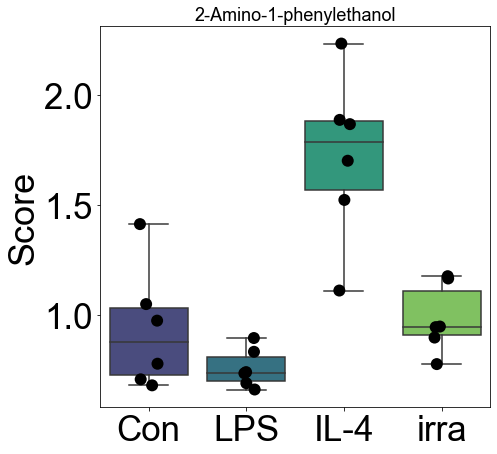

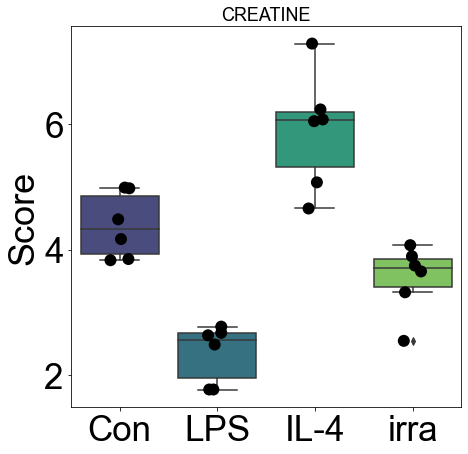

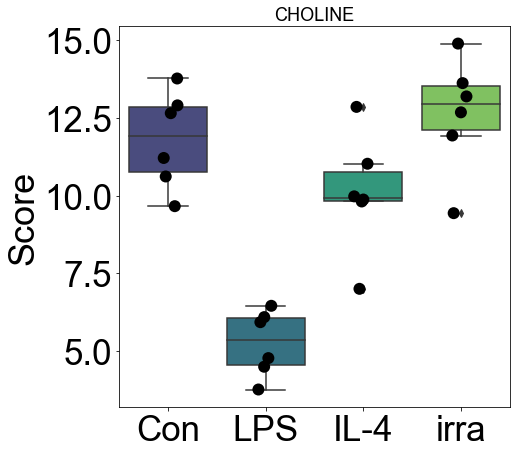

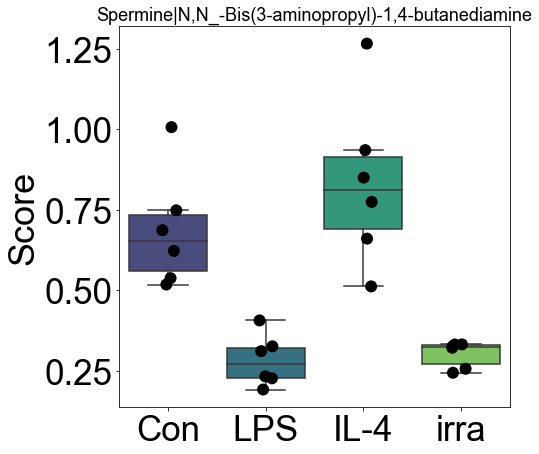

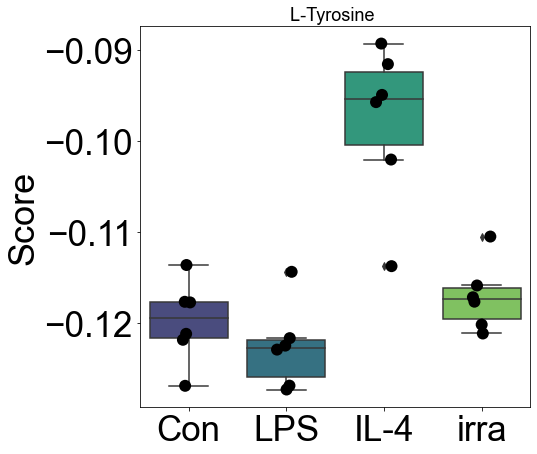

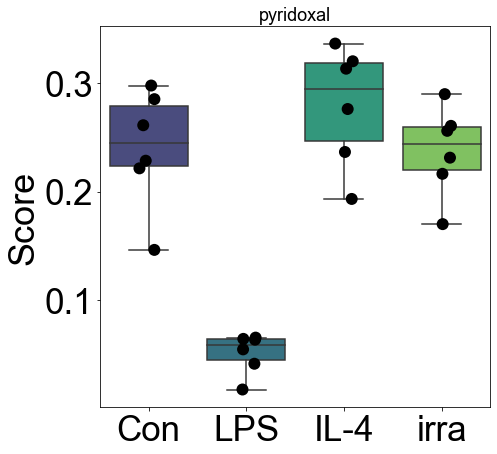

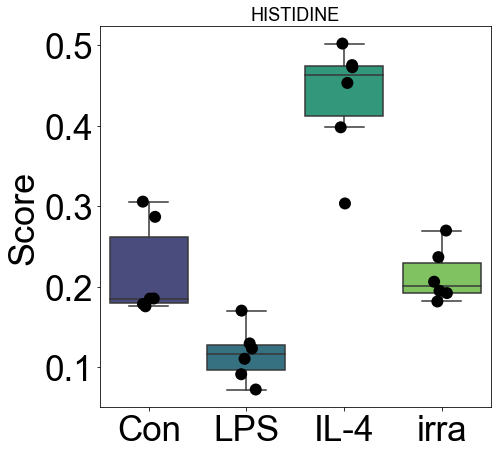

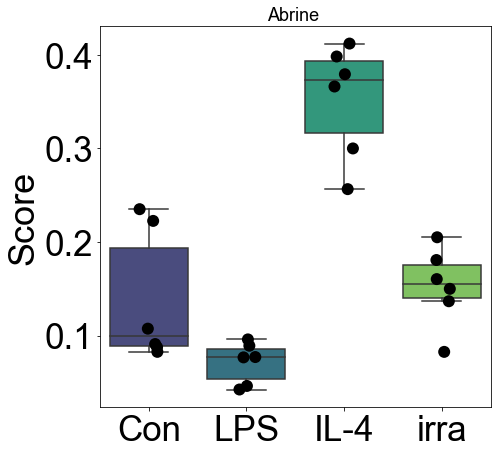

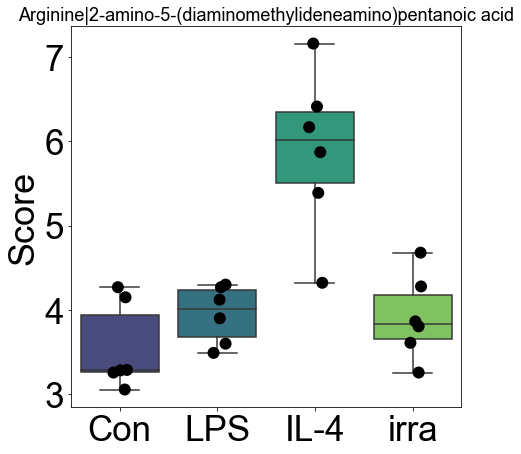

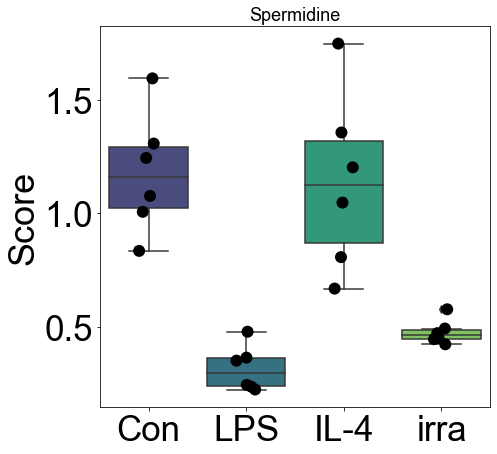

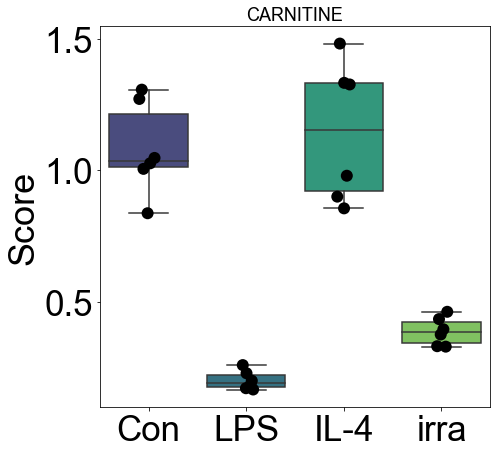

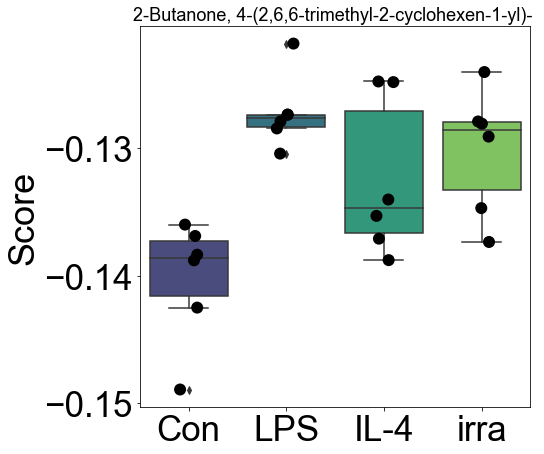

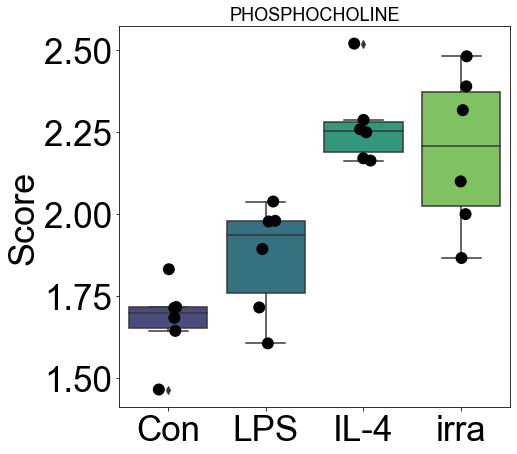

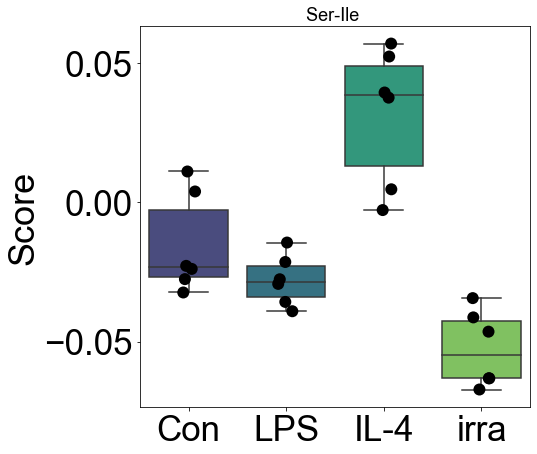

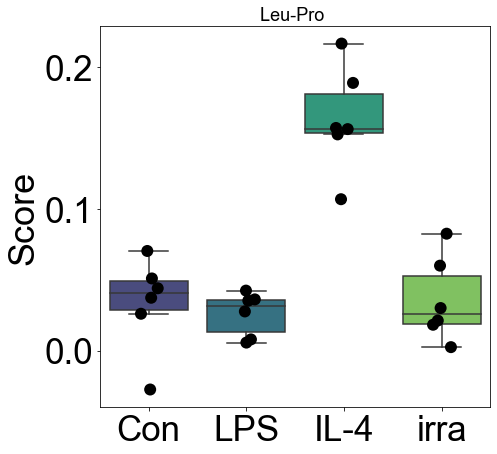

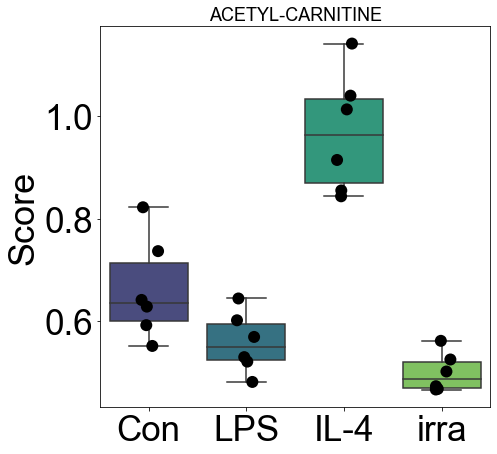

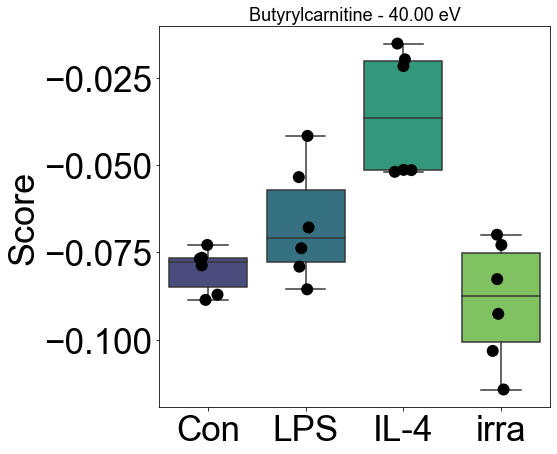

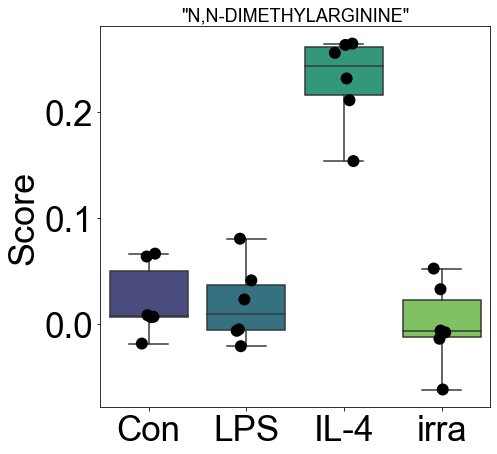

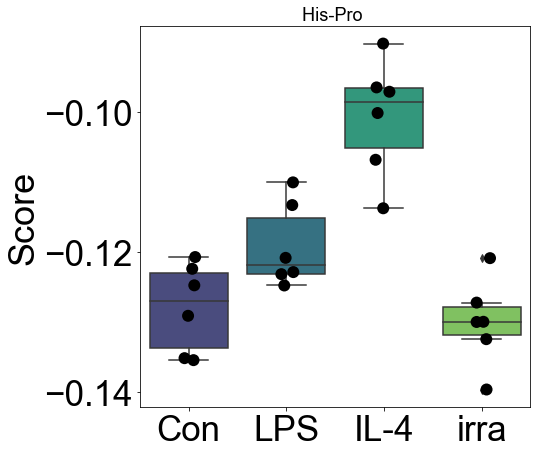

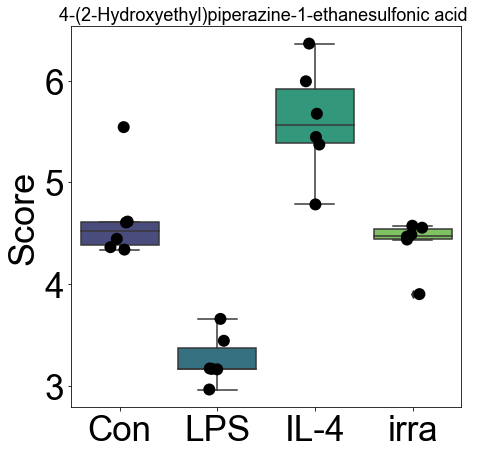

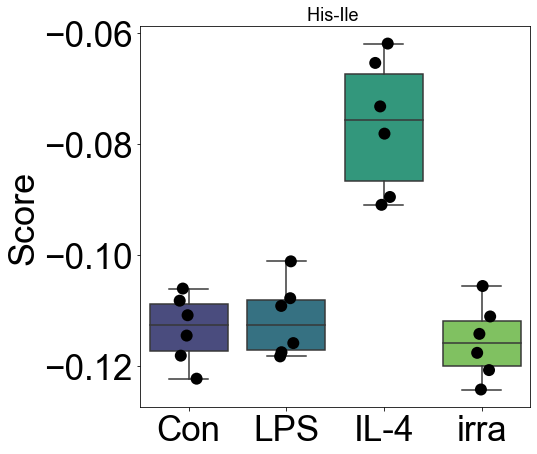

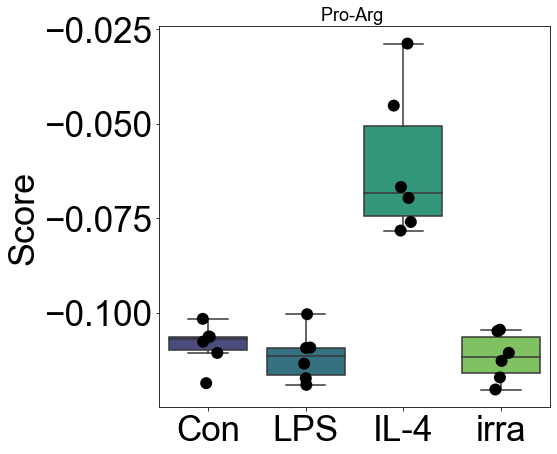

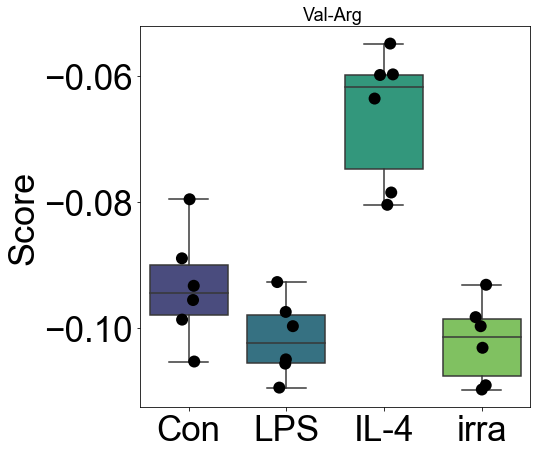

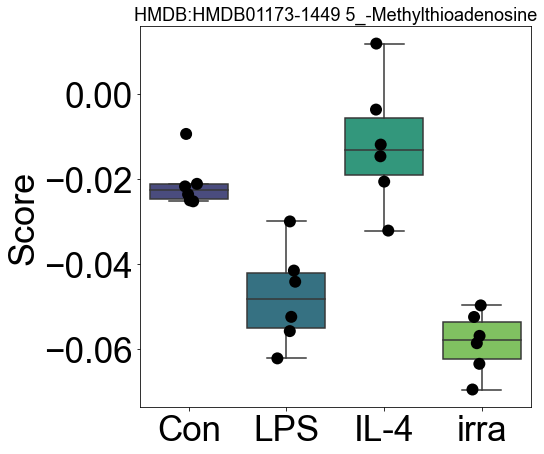

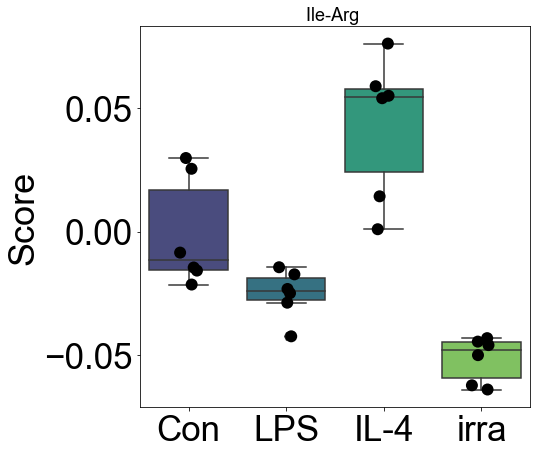

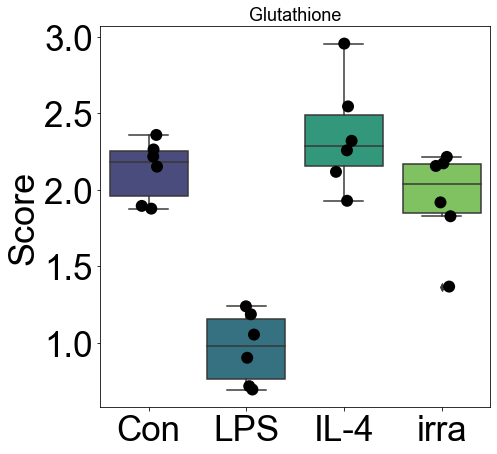

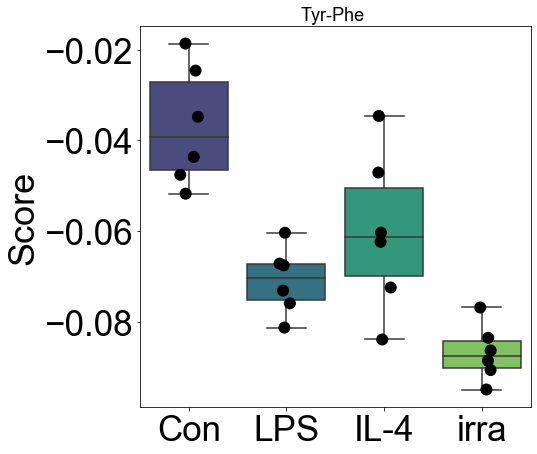

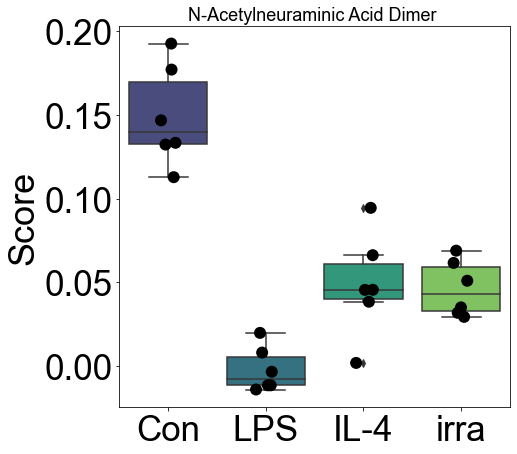

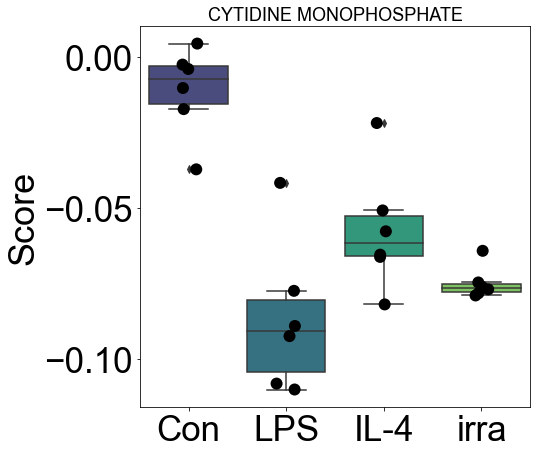

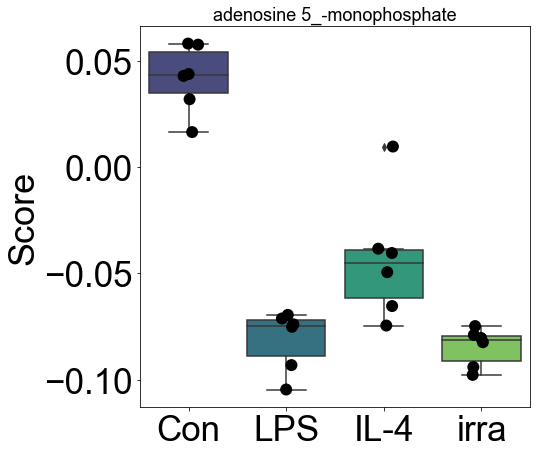

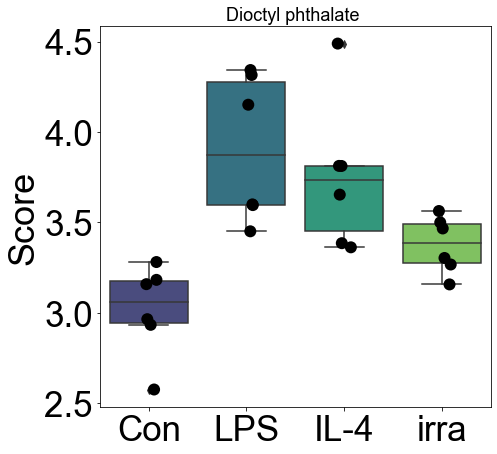

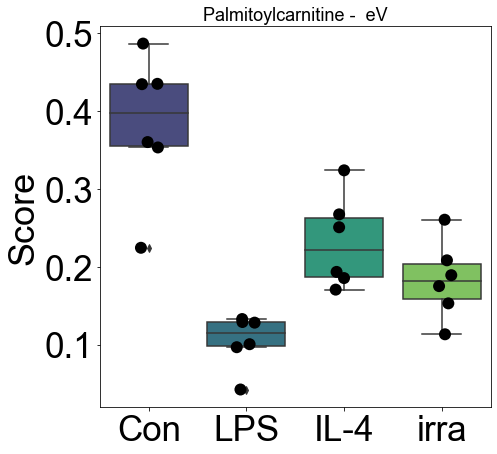

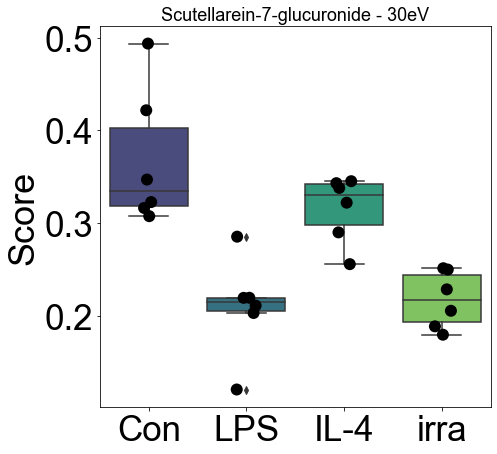

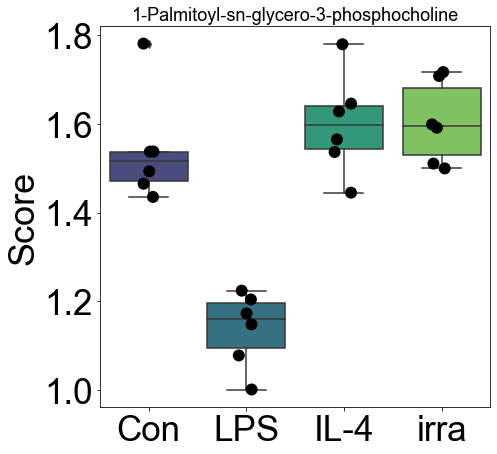

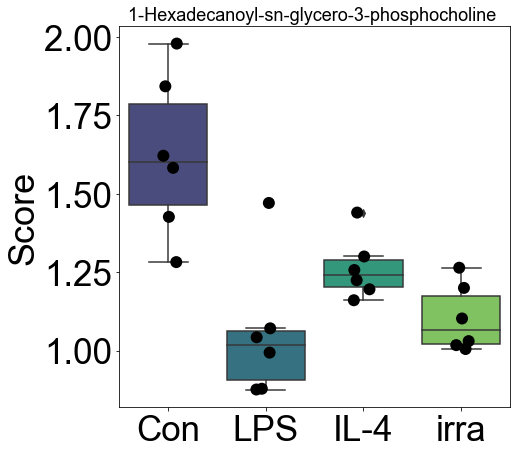

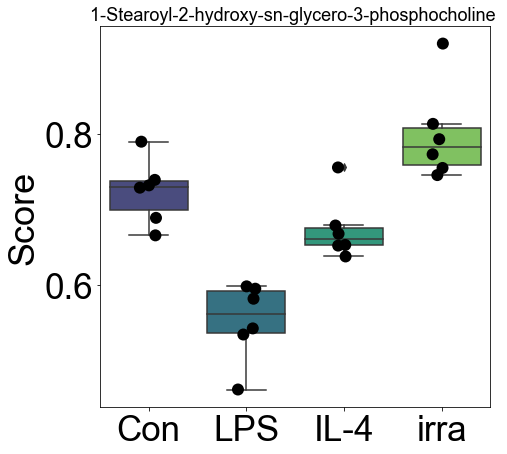

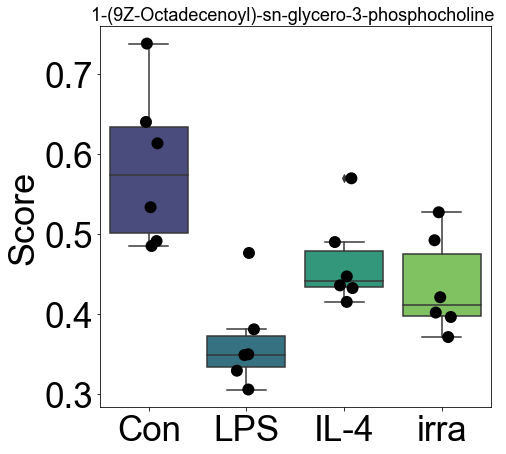

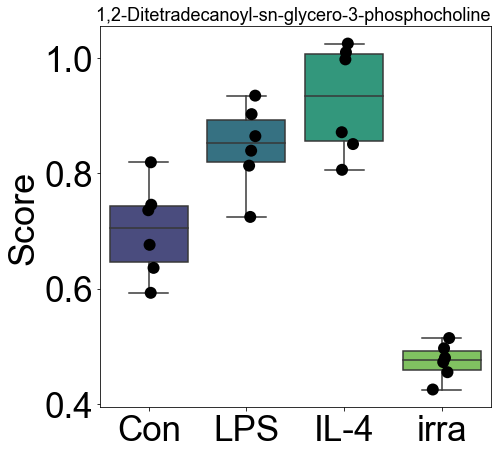

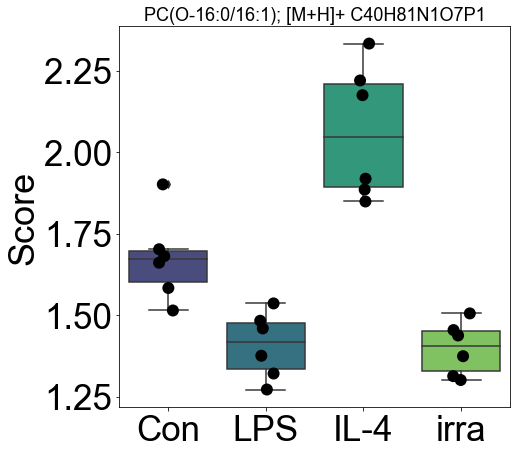

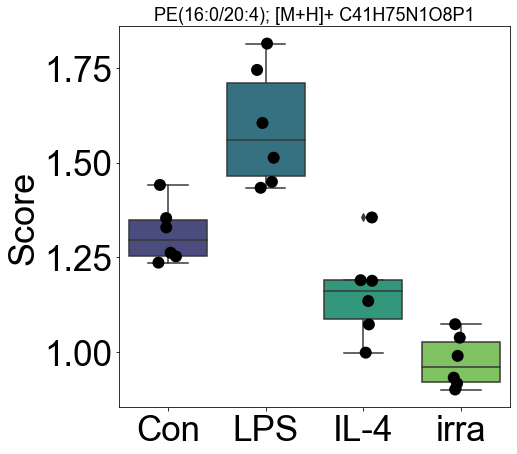

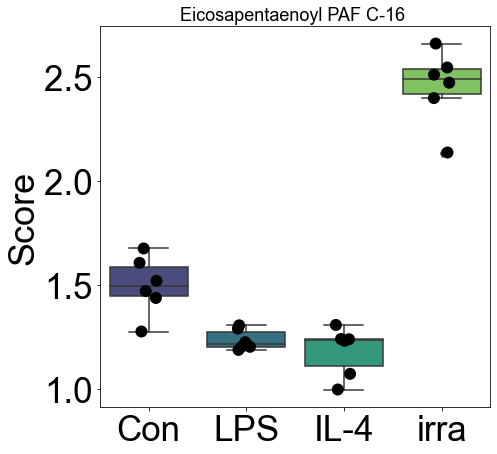

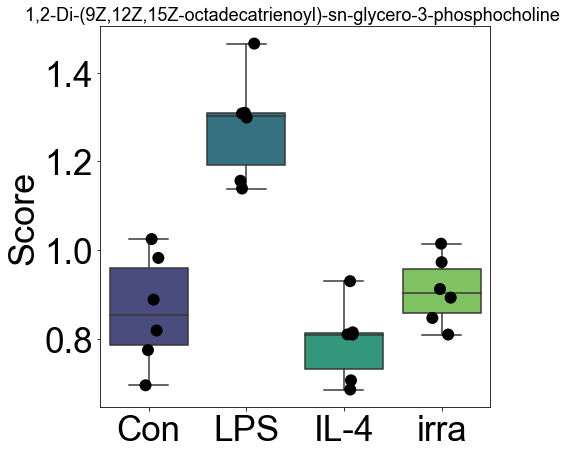

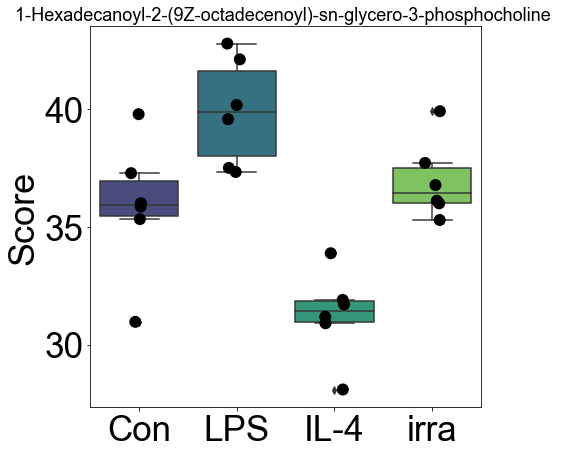

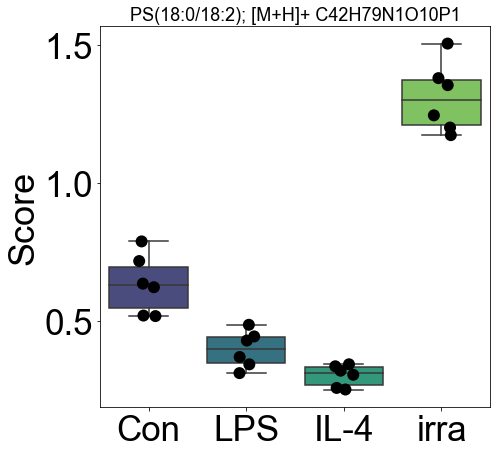

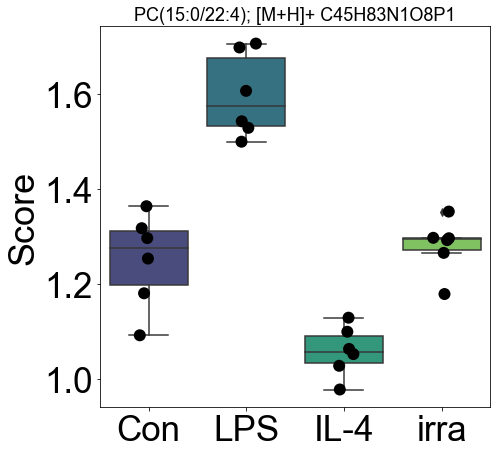

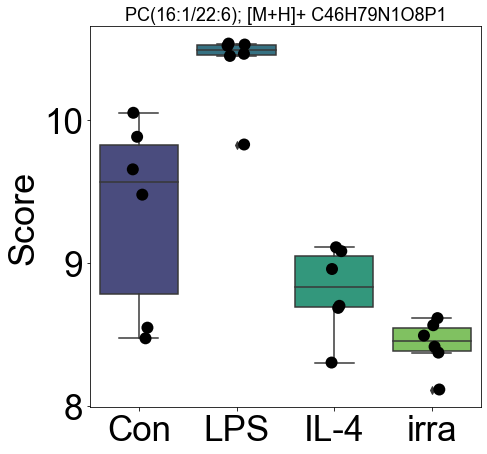

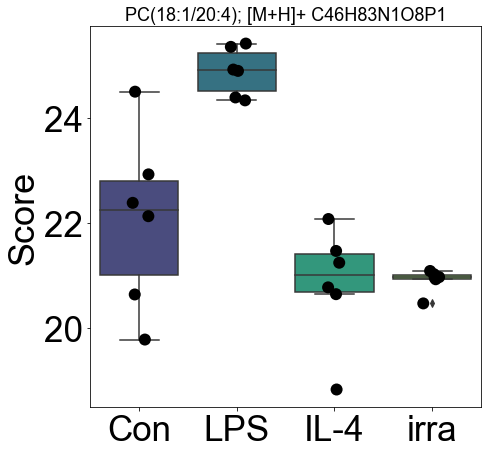

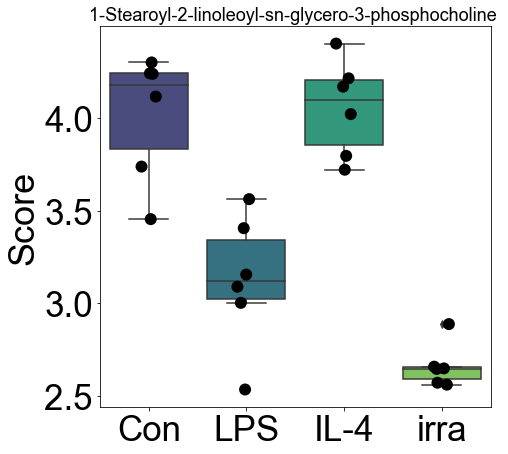

In [302]:

listname = final3.index

plot_fig(listname,df_name=final3)

In [90]:
# final3.to_excel(r'E:\\project7_SMAD\\figure_3_macro_clustering_analysis\\macro_metabolome_names.xlsx')

In [40]:
#
ori_64=df_sig_original[df_sig_original['mz_rounded'].isin (identified_mz_round)]
ori_64=ori_64.drop_duplicates(keep='first')
ori_64.to_excel(r'D:\\project7_SMAD\\figure_3_macro_clustering_analysis\\macro_metabolome_64mz_raw.xlsx')

In [95]:
# final.set_index('mz_rounded',inplace=True)
# final

In [78]:
kmeans=KMeans(n_clusters=5)
kmeans.fit(final[['Con','LPS','IL_4']])

final['kmeans']=kmeans.labels_
final

C:\Users\jymbc\AppData\Local\Temp/ipykernel_11416/4245355313.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final['kmeans']=kmeans.labels_


,Con,LPS,IL_4,kmeans
mz_rounded,,,,
132.077,0.110122,-1.179693,1.069571,4
104.107,0.884515,-1.219486,0.334970,0
129.139,0.298470,-1.102613,0.804143,0
156.077,-0.256258,-0.987323,1.243581,4
159.028,0.708818,-1.287562,0.578744,0
...,...,...,...,...
784.583,-0.924678,1.009126,-0.084448,1
788.615,0.545089,-1.165501,0.620412,0
828.551,0.555081,0.532405,-1.087486,1


(array([0.5, 1.5, 2.5]),
 [Text(0, 0.5, 'Con'), Text(0, 1.5, 'LPS'), Text(0, 2.5, 'IL_4')])

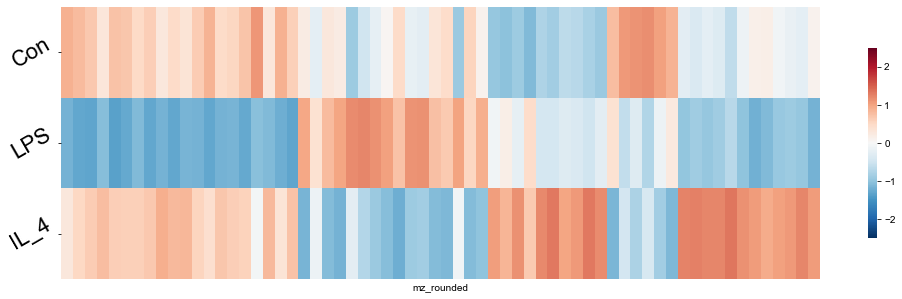

In [79]:
df_aa=final.sort_values(by=['kmeans'])
df_bb=df_aa.T
df_heat=df_bb.iloc[:3,:]

plt.figure(figsize=(17,5),edgecolor="#04253a")
matplotlib.rcParams['font.family'] = "Arial"
sns.heatmap(df_heat,  vmin=-2.5, vmax=2.5,cmap="RdBu_r",xticklabels=False,cbar_kws={"shrink": 0.7})
plt.xticks([])
plt.yticks(rotation=30)
plt.yticks(fontsize=22)

In [80]:
x=['Con','LPS','IL_4']

# take different cluster protein names out
sig_cluster4=final.loc[final['kmeans']==4]
sig_cluster3=final.loc[final['kmeans']==3]
sig_cluster2=final.loc[final['kmeans']==2]
sig_cluster1=final.loc[final['kmeans']==1]
sig_cluster0=final.loc[final['kmeans']==0]


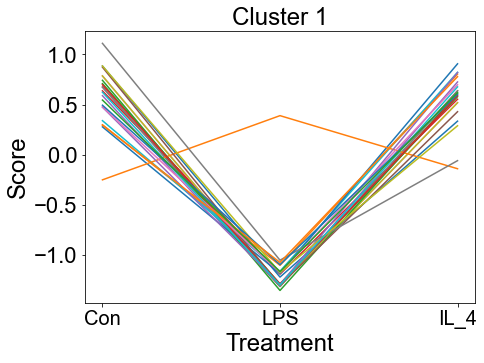

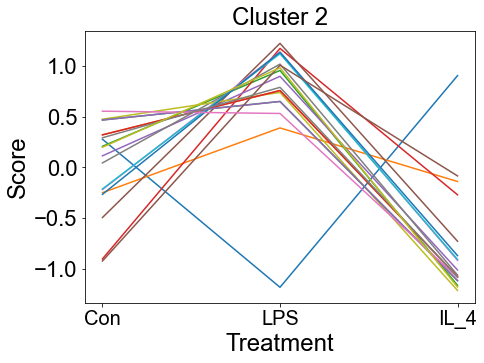

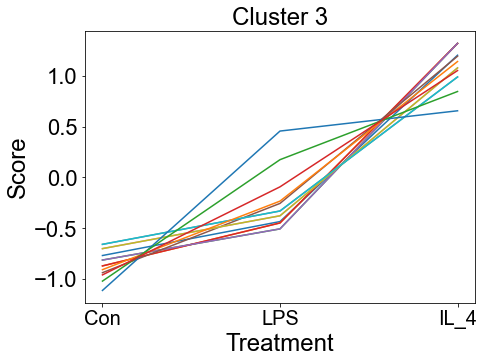

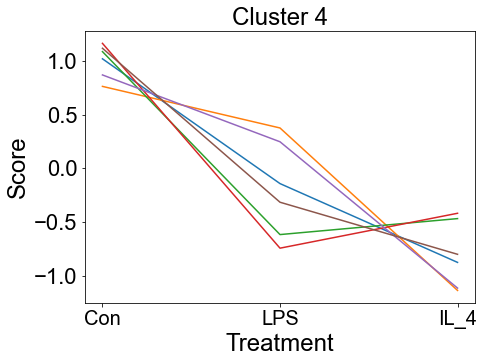

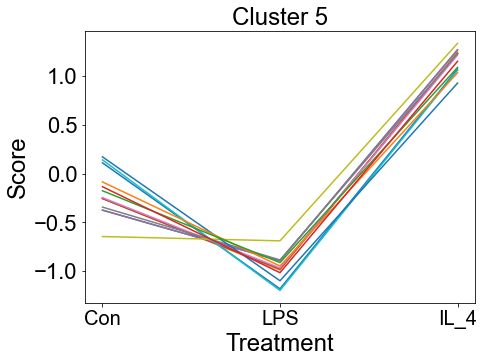

In [81]:
import matplotlib.pyplot as plt

# Create a dictionary of cluster names and corresponding data
cluster_data = {'Cluster 1': final.loc[list(sig_cluster0.index)],
                'Cluster 2': final.loc[list(sig_cluster1.index)],
                'Cluster 3': final.loc[list(sig_cluster2.index)],
                'Cluster 4': final.loc[list(sig_cluster3.index)],
                'Cluster 5': final.loc[list(sig_cluster4.index)]}

# Loop over the dictionary items to plot the data for each cluster
for title, data in cluster_data.items():
    plt.figure(figsize=(7, 5), edgecolor='#04253a')
    plt.rcParams['font.family'] = 'Arial'
    for i in range(len(data)):
        plt.plot(x, data.iloc[i, :3])
    plt.title(title, fontsize=24)
    plt.xlabel('Treatment', fontsize=24)
    plt.ylabel('Score', fontsize=24)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=22)
    plt.show()